# Análisis Preliminar — Datos Reales Auger SD-750 + UMD (2022-2026) PhaseII

Notebook de exploración a gran escala sobre el dataset procesado.  
Asume que los `.parquet` ya están generados por el pipeline paralelo.

**Contenido:**
1. Carga de todos los parquets
2. Resumen del dataset (estadísticas, flags de calidad)
3. Cobertura temporal (eventos por mes)
4. Espectro de energía por año
5. Señal UMD media vs energía
6. Perfil lateral de muones (LDF) por rango de energía
7. Mapa 2D: señal en el espacio (logE, r)
8. Evolución temporal de la calidad del detector
9. Verificación de isotropía azimutal

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('Imports OK')

Imports OK


## ⚙️ Configuración

> **Nota sobre los flags de rechazo:** los parquets incluyen  
> `is_sd_rejected` e `is_counter_rejected` como columnas booleanas.  
> El dataset limpio se define con `CLEAN_MASK` abajo.  
> Podés explorar los rechazados *sin* reprocesar los ADST.

In [2]:
PARQUET_DIR = '/home/lsilva/Github/parquet_datos_campo/'   # directorio con los .parquet
YEARS       = [2021, 2022, 2023, 2024, 2025, 2026]         # años procesados

# Subsets disponibles
SUBSETS = ['PhaseI', 'PhaseIISPMTPhaseIIBeta']

# ── SELECCIONÁ QUÉ SUBSET ANALIZAR EN ESTA CORRIDA ──
ACTIVE_SUBSET = 'PhaseIISPMTPhaseIIBeta' 
# ACTIVE_SUBSET = 'PhaseIISPMTPhaseIIBeta'

# Cortes de análisis (aplicados en pandas, no en lectura)
CLEAN_MASK = 'not is_sd_rejected and not is_counter_rejected and module_status == "candidate"'

# Bins de energía para los análisis
E_BINS  = np.arange(17.0, 21.1, 0.1)
E_MIDS  = 0.5 * (E_BINS[:-1] + E_BINS[1:])

# Bins de distancia al core
R_BINS  = np.arange(0, 1501, 100)   # 0 a 1500 m, pasos de 100 m
R_MIDS  = 0.5 * (R_BINS[:-1] + R_BINS[1:])

print(f'Directorio: {PARQUET_DIR}')
print(f'Subset activo para análisis: {ACTIVE_SUBSET}')

Directorio: /home/lsilva/Github/parquet_datos_campo/
Subset activo para análisis: PhaseIISPMTPhaseIIBeta


## 📂 Carga de datos

In [3]:
# ── Cargar todos los .parquet del subset activo ─────────────────────────
print(f'Buscando datos para el subset: {ACTIVE_SUBSET}')

# El '**' con recursive=True busca en todas las subcarpetas de año/mes automáticamente
pattern = os.path.join(PARQUET_DIR, '**', f'ADST_{ACTIVE_SUBSET}_*.parquet')
files = sorted(glob.glob(pattern, recursive=True))

print(f'Archivos encontrados: {len(files)}')

if not files:
    raise FileNotFoundError(f'No se encontraron parquets para {ACTIVE_SUBSET} en {PARQUET_DIR}')

# Cargamos año por año para mostrar progreso y detectar si falta alguno
dfs = []
for year in YEARS:
    # Filtramos los archivos que correspondan a este año particular
    year_files = [f for f in files if f'_{year}_' in os.path.basename(f)]
    
    if not year_files:
        print(f'  {year}: sin archivos')
        continue
        
    df_year = pd.concat([pd.read_parquet(f) for f in year_files], ignore_index=True)
    dfs.append(df_year)
    print(f'  {year}: {len(year_files):>3} archivos  |  {len(df_year):>8,} filas  |  {df_year["event_id"].nunique():>6,} eventos')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal para {ACTIVE_SUBSET}: {len(df):,} filas  |  {df["event_id"].nunique():,} eventos únicos')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')

Buscando datos para el subset: PhaseIISPMTPhaseIIBeta
Archivos encontrados: 1555
  2021: sin archivos
  2022: 319 archivos  |    87,709 filas  |  20,122 eventos
  2023: 360 archivos  |  1,988,418 filas  |  185,966 eventos
  2024: 363 archivos  |  3,107,987 filas  |  229,599 eventos
  2025: 365 archivos  |  4,251,968 filas  |  240,106 eventos
  2026: 148 archivos  |  2,221,970 filas  |  127,337 eventos

Total para PhaseIISPMTPhaseIIBeta: 11,658,052 filas  |  803,130 eventos únicos
Memoria: 2815 MB


## 📊 Resumen del dataset

In [4]:
# ── Resumen del dataset ────────────────────────────────────────────────
print('=== Dataset completo (sin filtros adicionales) ===')
print()

n_total_events  = df['event_id'].nunique()
n_total_modules = len(df)
n_counters      = df['counterId'].nunique()

print(f'Eventos únicos:            {n_total_events:>8,}')
print(f'Filas totales (módulos):   {n_total_modules:>8,}')
print(f'Counters UMD únicos:       {n_counters:>8}')
print(f'Módulos por evento (avg):  {n_total_modules/n_total_events:>8.1f}')
print()

# Flags de calidad
n_sd_rejected  = df['is_sd_rejected'].sum()
n_ctr_rejected = df['is_counter_rejected'].sum()
n_candidate    = (df['module_status'] == 'candidate').sum()

print('=== Flags de calidad (sobre total de filas) ===')
print(f'Módulos con SD rechazada:      {n_sd_rejected:>7,}  ({100*n_sd_rejected/n_total_modules:.1f}%)')
print(f'Módulos con Counter rechazado: {n_ctr_rejected:>7,}  ({100*n_ctr_rejected/n_total_modules:.1f}%)')
print(f'Módulos candidatos:            {n_candidate:>7,}  ({100*n_candidate/n_total_modules:.1f}%)')
print()

# Dataset limpio
df_clean = df.query(CLEAN_MASK).copy()
n_clean_ev = df_clean['event_id'].nunique()
print(f'=== Dataset limpio (sd_ok + counter_ok + candidate) ===')
print(f'Eventos con al menos 1 módulo limpio: {n_clean_ev:,}')
print(f'Filas limpias: {len(df_clean):,}  ({100*len(df_clean)/n_total_modules:.1f}% del total)')

=== Dataset completo (sin filtros adicionales) ===

Eventos únicos:             803,130
Filas totales (módulos):   11,658,052
Counters UMD únicos:             61
Módulos por evento (avg):      14.5

=== Flags de calidad (sobre total de filas) ===
Módulos con SD rechazada:      3,418,029  (29.3%)
Módulos con Counter rechazado: 2,336,306  (20.0%)
Módulos candidatos:            8,380,298  (71.9%)

=== Dataset limpio (sd_ok + counter_ok + candidate) ===
Eventos con al menos 1 módulo limpio: 729,287
Filas limpias: 7,382,813  (63.3% del total)


## 📅 Cobertura temporal

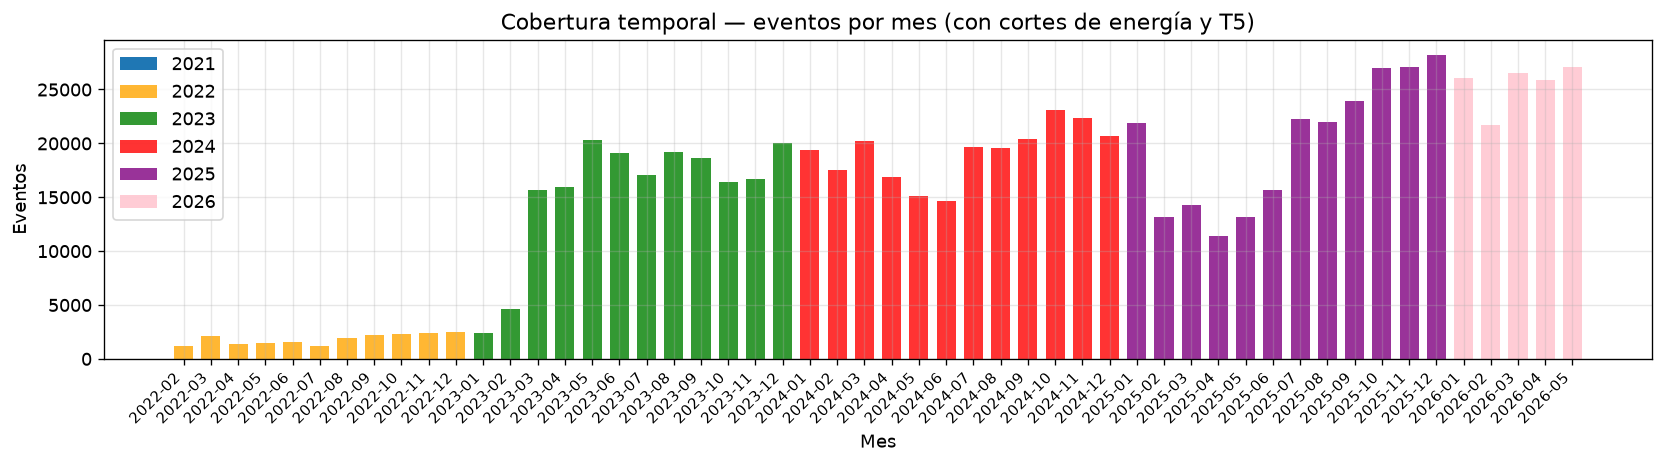

Meses con datos: 52
Promedio eventos/mes: 15445  |  min: 1185  |  max: 28217


In [7]:
# ── Cobertura temporal: eventos por mes ────────────────────────────────
evts_per_event = df.drop_duplicates('event_id')[['event_id','year','month','logE_REC']].copy()
counts = evts_per_event.groupby(['year','month']).size().reset_index(name='n_events')

fig, ax = plt.subplots(figsize=(14, 4))
colors_year = {2021: 'steelblue', 2022: 'orange', 2023: 'green', 2024: 'red', 2025: 'purple', 2026: 'pink'}

for year in YEARS:
    sub = counts[counts['year'] == year]
    x   = [f'{year}-{m:02d}' for m in sub['month']]
    ax.bar(x, sub['n_events'], color=colors_year.get(year, 'gray'),
           label=str(year), alpha=0.8, width=0.7)

ax.set_xlabel('Mes')
ax.set_ylabel('Eventos')
ax.set_title('Cobertura temporal — eventos por mes (con cortes de energía y T5)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Meses con datos: {len(counts)}')
print(f'Promedio eventos/mes: {counts["n_events"].mean():.0f}  |  min: {counts["n_events"].min()}  |  max: {counts["n_events"].max()}')

## ⚡ Espectro de energía

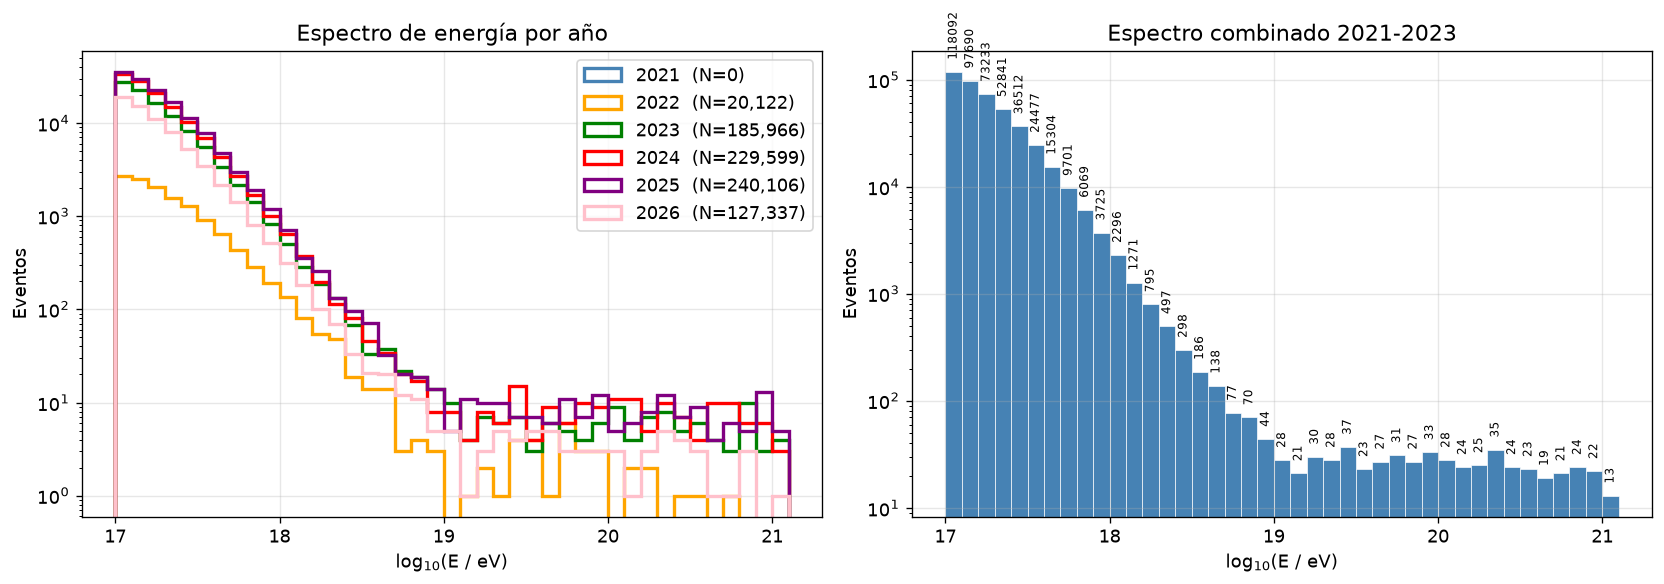

Estadísticas del espectro (dataset limpio):
  [17.00, 17.10]  N=118092
  [17.10, 17.20]  N=97690
  [17.20, 17.30]  N=73233
  [17.30, 17.40]  N=52841
  [17.40, 17.50]  N=36512
  [17.50, 17.60]  N=24477
  [17.60, 17.70]  N=15304
  [17.70, 17.80]  N= 9701
  [17.80, 17.90]  N= 6069
  [17.90, 18.00]  N= 3725
  [18.00, 18.10]  N= 2296
  [18.10, 18.20]  N= 1271
  [18.20, 18.30]  N=  795
  [18.30, 18.40]  N=  497
  [18.40, 18.50]  N=  298
  [18.50, 18.60]  N=  186
  [18.60, 18.70]  N=  138
  [18.70, 18.80]  N=   77
  [18.80, 18.90]  N=   70
  [18.90, 19.00]  N=   44
  [19.00, 19.10]  N=   28
  [19.10, 19.20]  N=   21
  [19.20, 19.30]  N=   30
  [19.30, 19.40]  N=   28
  [19.40, 19.50]  N=   37
  [19.50, 19.60]  N=   23
  [19.60, 19.70]  N=   27
  [19.70, 19.80]  N=   31
  [19.80, 19.90]  N=   27
  [19.90, 20.00]  N=   33
  [20.00, 20.10]  N=   28
  [20.10, 20.20]  N=   24
  [20.20, 20.30]  N=   25
  [20.30, 20.40]  N=   35
  [20.40, 20.50]  N=   24
  [20.50, 20.60]  N=   23
  [20.60, 20.70]  N

In [8]:
# ── Espectro de energía por año ────────────────────────────────────────
events_u = df.drop_duplicates('event_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: histograma apilado por año
ax = axes[0]
for year in YEARS:
    sub = events_u[events_u['year'] == year]['logE_REC']
    ax.hist(sub, bins=E_BINS, histtype='step', lw=2,
            label=f'{year}  (N={len(sub):,})',
            color=colors_year.get(year, 'gray'))
ax.set_yscale('log')
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('Eventos')
ax.set_title('Espectro de energía por año')
ax.legend()

# Panel der: espectro combinado + conteo por bin
ax = axes[1]
n_per_bin, _, _ = ax.hist(events_u['logE_REC'], bins=E_BINS,
                           color='steelblue', edgecolor='white', lw=0.4)
ax.set_yscale('log')
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('Eventos')
ax.set_title('Espectro combinado 2021-2023')

# Anotar cada bin con el N
for mid, n in zip(E_MIDS, n_per_bin):
    if n > 0:
        ax.text(mid, n*1.3, f'{int(n)}', ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

print('Estadísticas del espectro (dataset limpio):')
for lo, hi, mid, n in zip(E_BINS[:-1], E_BINS[1:], E_MIDS, n_per_bin):
    print(f'  [{lo:.2f}, {hi:.2f}]  N={int(n):>5}')

## 🎯 Señal UMD vs energía

Promediamos `nMuones_REC` por módulo a nivel de evento,  
luego binamos por energía para ver la dependencia.

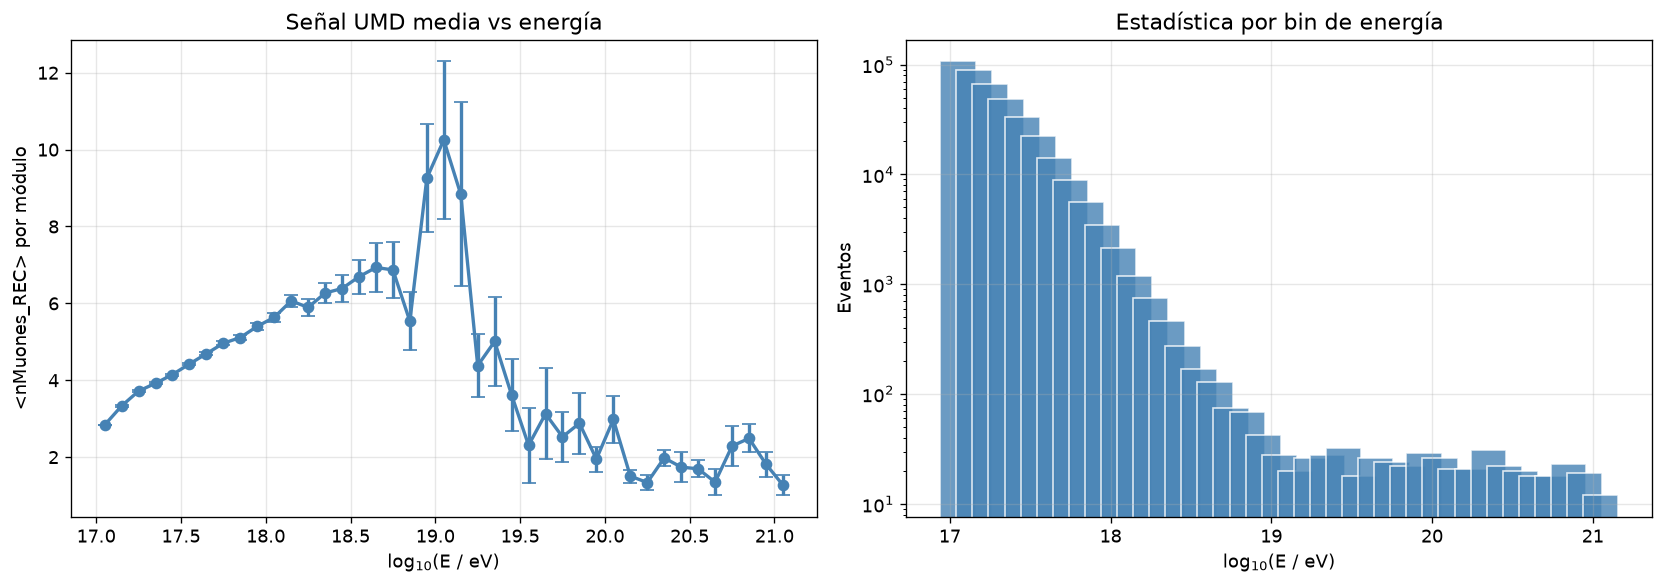

nMuones medio por módulo vs logE (bins con N >= 10):
 E_bin  n_events  nMu_mean   nMu_std  nMod_mean
 17.05    107065  2.833799  3.905684   9.419894
 17.15     88918  3.329486  4.659590  10.285825
 17.25     66698  3.716158  4.910646  11.255120
 17.35     48313  3.918673  4.685297  12.322853
 17.45     33451  4.146048  4.918863  13.466324
 17.55     22515  4.421412  4.929017  14.646502
 17.65     14104  4.688164  5.337164  16.123369
 17.75      8943  4.960105  5.222366  17.744828
 17.85      5620  5.109688  5.013136  18.780427
 17.95      3461  5.399237  5.185947  20.642589
 18.05      2133  5.634912  5.302239  21.688701
 18.15      1182  6.062424  5.610034  24.061760
 18.25       750  5.892170  5.901675  24.932000
 18.35       458  6.266679  5.362487  26.279476
 18.45       275  6.384187  5.720386  27.720000
 18.55       170  6.691026  5.802722  29.047059
 18.65       129  6.931654  7.247314  27.240310
 18.75        74  6.868400  6.331152  30.635135
 18.85        68  5.532184  6.24591

In [9]:
# ── nMuones promedio vs logE (usando dataset limpio) ──────────────────
# Agrupamos a nivel de evento (promedio de módulos por evento)
ev_level = (
    df_clean
    .groupby('event_id')
    .agg(
        logE_REC   = ('logE_REC', 'first'),
        theta_REC  = ('theta_REC', 'first'),
        year       = ('year', 'first'),
        nMu_mean   = ('nMuones_REC', 'mean'),   # promedio de módulos
        nMu_sum    = ('nMuones_REC', 'sum'),    # suma de módulos
        n_modules  = ('moduleId', 'count'),     # cuántos módulos contribuyeron
    )
    .reset_index()
)

# Binear por energía
ev_level['E_bin'] = pd.cut(ev_level['logE_REC'], bins=E_BINS, labels=E_MIDS)
stats_E = (
    ev_level
    .groupby('E_bin', observed=True)
    .agg(
        n_events    = ('event_id', 'count'),
        nMu_mean    = ('nMu_mean', 'mean'),
        nMu_std     = ('nMu_mean', 'std'),
        nMu_sum_mean = ('nMu_sum', 'mean'),
        nMod_mean   = ('n_modules', 'mean'),
    )
    .reset_index()
)
stats_E['E_bin'] = stats_E['E_bin'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mask = stats_E['n_events'] >= 10  # bins con estadística mínima
ax.errorbar(stats_E.loc[mask, 'E_bin'],
            stats_E.loc[mask, 'nMu_mean'],
            yerr=stats_E.loc[mask, 'nMu_std'] / np.sqrt(stats_E.loc[mask, 'n_events']),
            fmt='o-', color='steelblue', capsize=4, lw=2)
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('<nMuones_REC> por módulo')
ax.set_title('Señal UMD media vs energía')

ax = axes[1]
ax.bar(stats_E.loc[mask, 'E_bin'], stats_E.loc[mask, 'n_events'],
       width=0.22, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('Eventos')
ax.set_title('Estadística por bin de energía')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print('nMuones medio por módulo vs logE (bins con N >= 10):')
print(stats_E[mask][['E_bin','n_events','nMu_mean','nMu_std','nMod_mean']].to_string(index=False))

## 📐 Perfil lateral de muones (LDF)

La LDF del UMD: cómo cae la señal con la distancia al core,  
separada por rangos de energía.

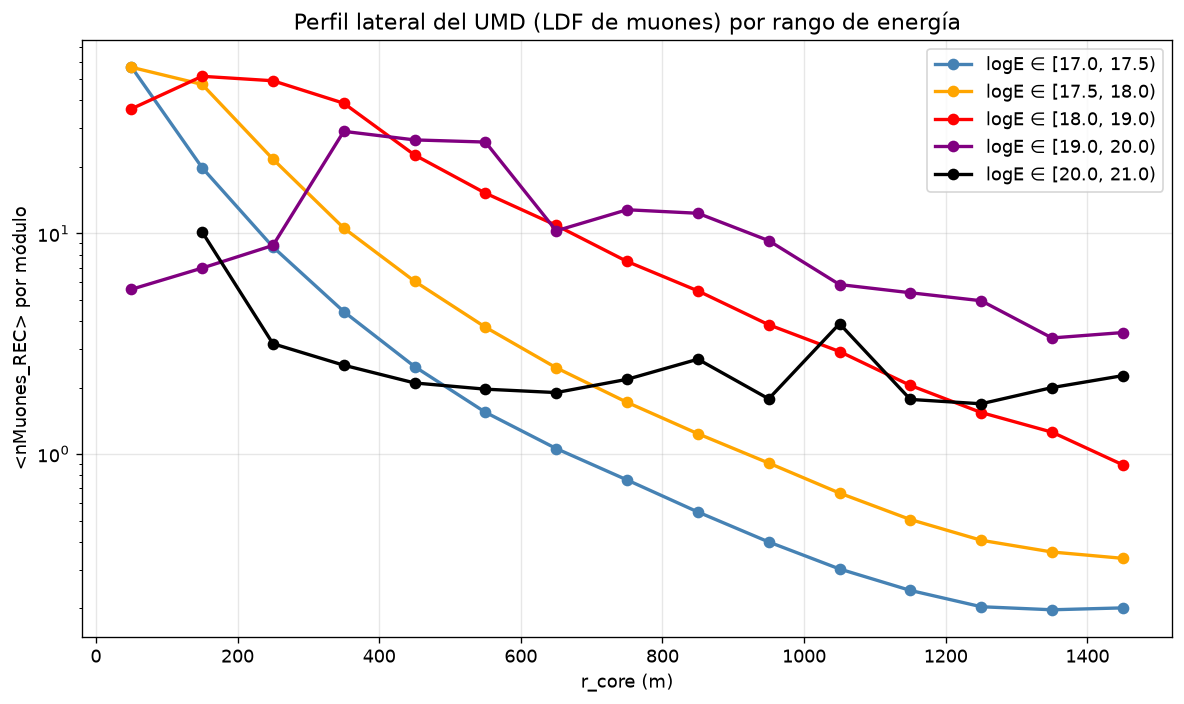

In [10]:
# ── nMuones promedio vs distancia al core (LDF del UMD) ───────────────
# Binear por r_core y por bins de energía simultáneamente
df_clean['R_bin'] = pd.cut(df_clean['r_core'], bins=R_BINS, labels=R_MIDS)
df_clean['E_bin'] = pd.cut(df_clean['logE_REC'], bins=E_BINS, labels=E_MIDS)

ldf = (
    df_clean
    .groupby(['E_bin', 'R_bin'], observed=True)
    .agg(nMu_mean=('nMuones_REC','mean'), n=('nMuones_REC','count'))
    .reset_index()
)
ldf['E_bin'] = ldf['E_bin'].astype(float)
ldf['R_bin'] = ldf['R_bin'].astype(float)

# Seleccionamos 3 rangos de energía representativos
E_ranges = [(17.0, 17.5, 'steelblue'), (17.5, 18.0, 'orange'), (18.0, 19.0, 'red'), (19.0, 20.0, 'purple'), (20.0, 21.0, 'black')]

fig, ax = plt.subplots(figsize=(10, 6))
for e_lo, e_hi, color in E_ranges:
    sub = ldf[(ldf['E_bin'] >= e_lo) & (ldf['E_bin'] < e_hi) & (ldf['n'] >= 5)]
    sub_r = sub.groupby('R_bin').agg(nMu=('nMu_mean','mean'), n=('n','sum')).reset_index()
    ax.plot(sub_r['R_bin'], sub_r['nMu'], 'o-', color=color, lw=2,
            label=f'logE ∈ [{e_lo:.1f}, {e_hi:.1f})')

ax.set_xlabel('r_core (m)')
ax.set_ylabel('<nMuones_REC> por módulo')
ax.set_title('Perfil lateral del UMD (LDF de muones) por rango de energía')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 🗺️ Mapa 2D de señal

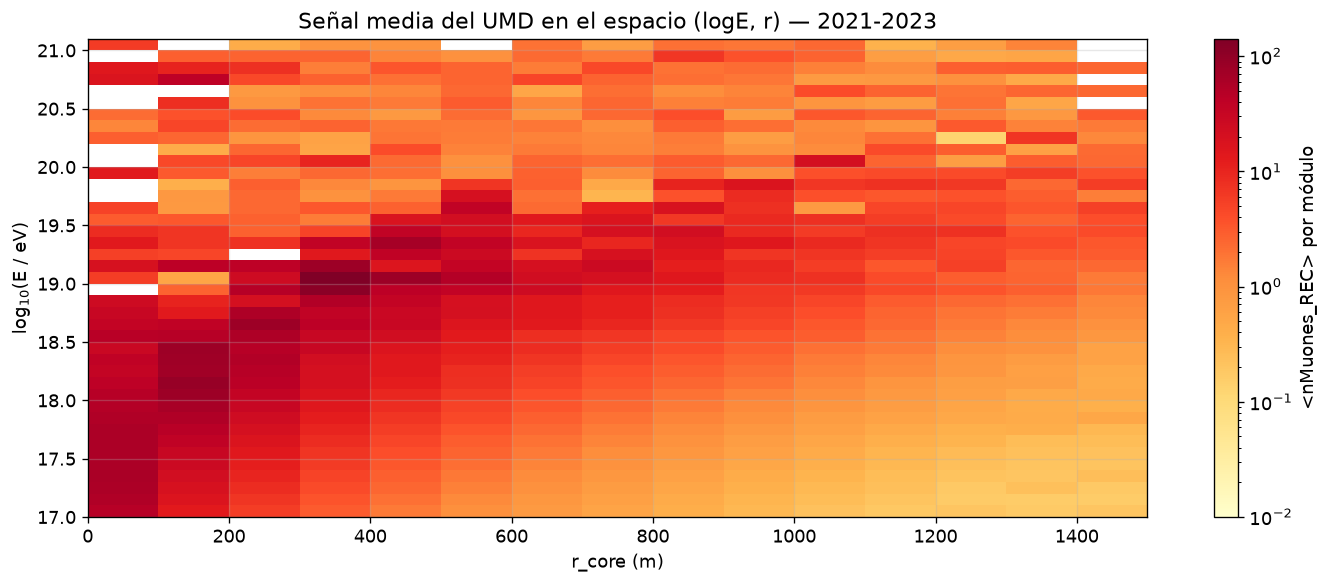

In [11]:
# ── Mapa 2D: <nMuones> vs (logE, r_core) ─────────────────────────────
pivot = (
    df_clean
    .groupby(['E_bin','R_bin'], observed=True)['nMuones_REC']
    .mean()
    .unstack('R_bin')
)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

data_masked = np.ma.masked_invalid(pivot.values)   # NaN → ignorados por pcolormesh
vmax = float(np.nanmax(pivot.values))              # max ignorando NaN

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(
    pivot.columns, pivot.index, data_masked,
    cmap='YlOrRd',
    norm=mcolors.LogNorm(vmin=0.01, vmax=vmax),
    shading='auto'
)
plt.colorbar(im, ax=ax, label='<nMuones_REC> por módulo')
ax.set_xlabel('r_core (m)')
ax.set_ylabel('log$_{10}$(E / eV)')
ax.set_title('Señal media del UMD en el espacio (logE, r) — 2021-2023')
plt.tight_layout()
plt.show()

## 🔍 Evolución temporal de la calidad

Usamos los flags `is_sd_rejected` e `is_counter_rejected`  
para monitorear el uptime del detector a lo largo del tiempo.

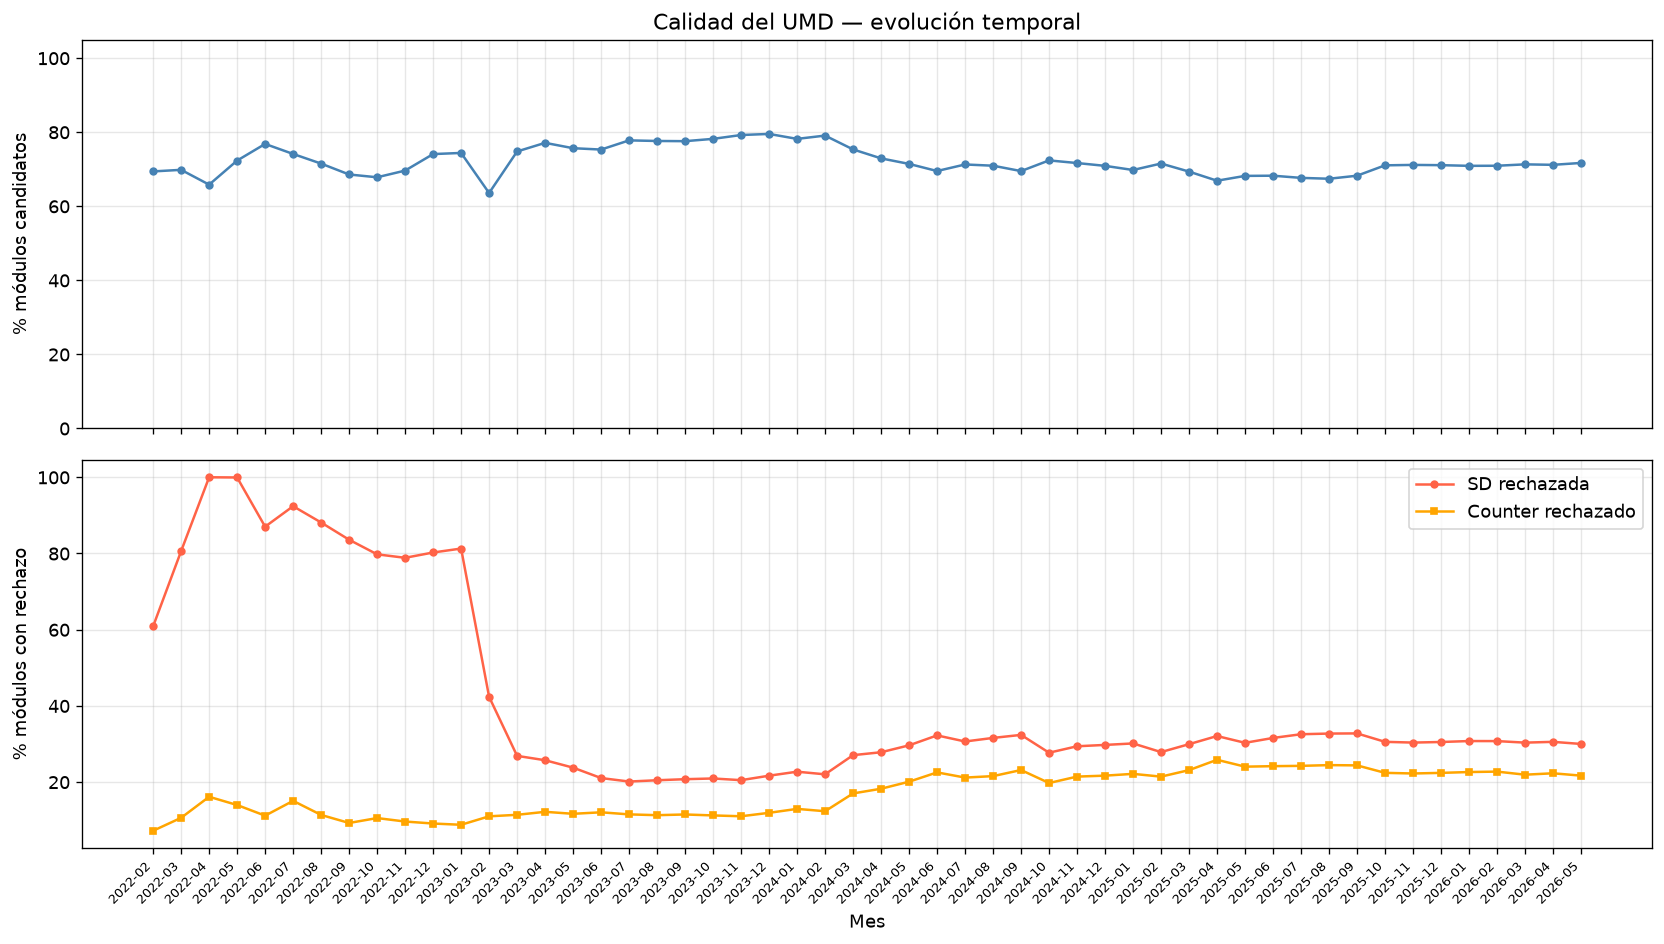

Fracción media de rechazo por año:
  2021: SD rechazada=nan%  Counter rechazado=nan%
  2022: SD rechazada=83.5%  Counter rechazado=10.8%
  2023: SD rechazada=22.8%  Counter rechazado=11.6%
  2024: SD rechazada=28.8%  Counter rechazado=19.7%
  2025: SD rechazada=31.0%  Counter rechazado=23.3%
  2026: SD rechazada=30.5%  Counter rechazado=22.2%


In [12]:
# ── Evolución temporal de la calidad del detector ─────────────────────
# Fracción de módulos candidatos por mes → proxy del uptime del UMD
df['ym'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
quality = (
    df
    .groupby('ym')
    .apply(lambda g: pd.Series({
        'frac_candidate':      (g['module_status'] == 'candidate').mean(),
        'frac_sd_rejected':    g['is_sd_rejected'].mean(),
        'frac_ctr_rejected':   g['is_counter_rejected'].mean(),
        'n_modules':           len(g),
    }))
    .reset_index()
    .sort_values('ym')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(quality['ym'], quality['frac_candidate'] * 100, 'o-',
        color='steelblue', lw=1.5, ms=4)
ax.set_ylabel('% módulos candidatos')
ax.set_title('Calidad del UMD — evolución temporal')
ax.set_ylim(0, 105)

ax = axes[1]
ax.plot(quality['ym'], quality['frac_sd_rejected'] * 100, 'o-',
        color='tomato', lw=1.5, ms=4, label='SD rechazada')
ax.plot(quality['ym'], quality['frac_ctr_rejected'] * 100, 's-',
        color='orange', lw=1.5, ms=4, label='Counter rechazado')
ax.set_ylabel('% módulos con rechazo')
ax.set_xlabel('Mes')
ax.legend()

for ax in axes:
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Fracción media de rechazo por año:')
for year in YEARS:
    sub = df[df['year'] == year]
    fsd  = sub['is_sd_rejected'].mean() * 100
    fctr = sub['is_counter_rejected'].mean() * 100
    print(f'  {year}: SD rechazada={fsd:.1f}%  Counter rechazado={fctr:.1f}%')

## 🧭 Verificación de isotropía

El azimuth relativo `phi_plane_sp` debe ser uniforme  
(el detector es isotrópico). Si hay una asimetría, indica  
algún problema en la geometría o en los cortes.

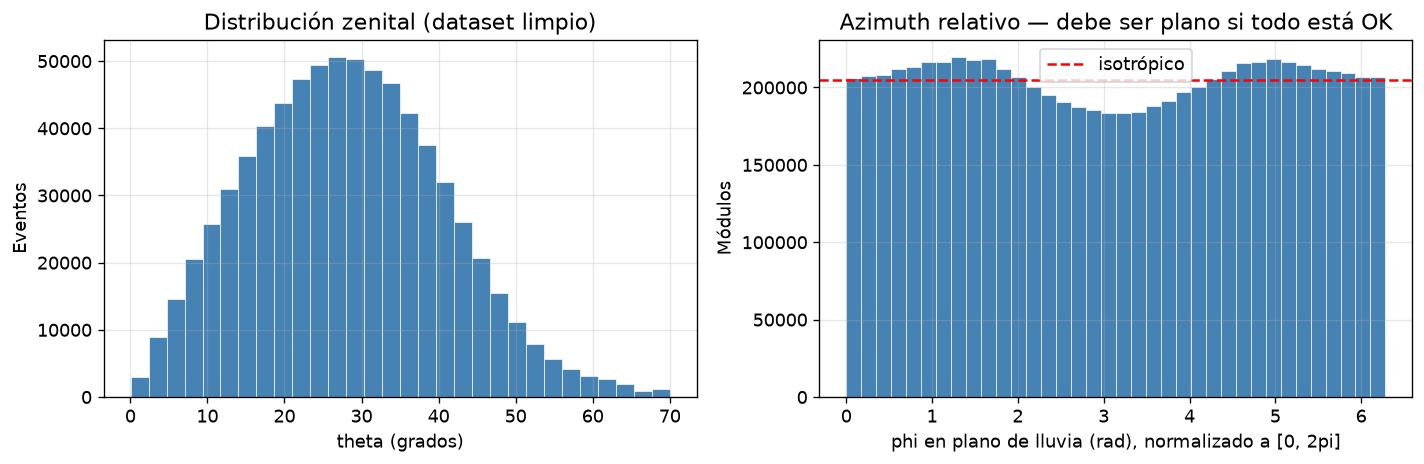

Test isotropía phi (chi2/dof): 657.69  (esperado ~1.0 si es isotrópico)


In [13]:
# ── Distribución de theta y phi_plane_sp ──────────────────────────────
events_u_clean = df_clean.drop_duplicates('event_id')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(events_u_clean['theta_REC'], bins=30,
        color='steelblue', edgecolor='white', lw=0.4)
ax.set_xlabel('theta (grados)')
ax.set_ylabel('Eventos')
ax.set_title('Distribución zenital (dataset limpio)')

ax = axes[1]
# phi_plane_sp en [-pi, pi] → lo normalizamos a [0, 2pi] para verificar isotropía
phi_norm = df_clean['phi_plane_sp'] % (2 * np.pi)
ax.hist(phi_norm, bins=36, color='steelblue', edgecolor='white', lw=0.4)
ax.axhline(len(phi_norm) / 36, color='red', lw=1.5, ls='--', label='isotrópico')
ax.set_xlabel('phi en plano de lluvia (rad), normalizado a [0, 2pi]')
ax.set_ylabel('Módulos')
ax.set_title('Azimuth relativo — debe ser plano si todo está OK')
ax.legend()

plt.tight_layout()
plt.show()

# Test de isotropía rápido
hist_phi, _ = np.histogram(phi_norm, bins=36)
chi2_iso = np.sum((hist_phi - hist_phi.mean())**2 / hist_phi.mean())
print(f'Test isotropía phi (chi2/dof): {chi2_iso/35:.2f}  (esperado ~1.0 si es isotrópico)')

Módulos tras calidad y cortes cinemáticos: 8587


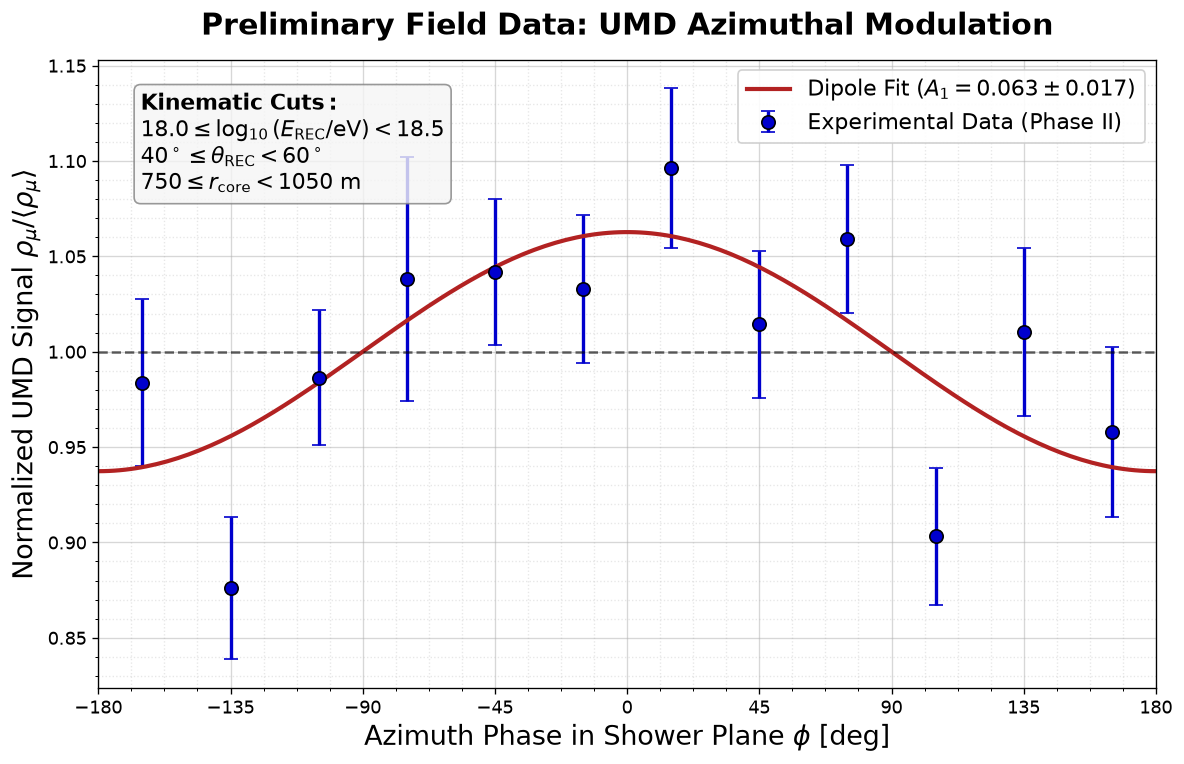

In [14]:
# =============================================================================
# CELDA: EXTRACCIÓN DE ASIMETRÍA EN DATOS DE CAMPO (VERSIÓN CORREGIDA)
# =============================================================================

# 1. Definir el modelo armónico
def harmonic_model(phi_deg, A1):
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))

# Mapeo EXACTO basado en la función readADST_surface_data_v19
col_energia = 'logE_REC'     # Ya es log10(E)
col_theta   = 'theta_REC'    # ¡Ya está en grados!
col_radio   = 'r_core'       # Distancia al eje en metros
col_phi     = 'phi_plane_sp' # Fase en el plano en radianes [-pi, pi]
col_senal   = 'nMuones_REC'  # Muones estimados

# 1. FILTRO DE CALIDAD EXPERIMENTAL (¡Fundamental en datos de campo!)
# Solo usamos estaciones y counters no rechazados
mask_quality = (~df_clean['is_sd_rejected']) & (~df_clean['is_counter_rejected'])
df_good = df_clean[mask_quality].copy()

# 2. Conversión de unidades (theta ya está en grados, solo convertimos phi)
df_good['phi_deg'] = np.rad2deg(df_good[col_phi])

# 3. Aplicación de Cortes Cinemáticos Estrictos
mask_energy = (df_good[col_energia] >= 18.0) & (df_good[col_energia] < 18.5)
mask_theta  = (df_good[col_theta] >= 50.0) & (df_good[col_theta] < 60.0)
mask_radius = (df_good[col_radio] >= 750) & (df_good[col_radio] < 1250)

df_cut = df_good[mask_energy & mask_theta & mask_radius].copy()

print(f"Módulos tras calidad y cortes cinemáticos: {len(df_cut)}")

# 4. Bineado Azimutal (12 bines de 30 grados)
phi_bins = np.linspace(-180, 180, 13)
phi_centers = 0.5 * (phi_bins[1:] + phi_bins[:-1])

# Asignamos a cada evento su centro de bin correspondiente
df_cut['bin_phi_center'] = pd.cut(df_cut['phi_deg'], bins=phi_bins, labels=phi_centers)

# Agrupamos para calcular la media y el error estándar (SEM) de la señal
st = df_cut.groupby('bin_phi_center', observed=False)[col_senal].agg(['mean', 'sem', 'count']).dropna()

# Filtramos bines con muy pocos detectores para evitar ruido estadístico
st = st[st['count'] > 15] 

phi_c = st.index.astype(float).values
y_means = st['mean'].values
y_errs = st['sem'].values

# 5. Normalización del Observable
norm = np.nanmean(y_means)
if norm > 0:
    y_norm = y_means / norm
    y_err_norm = y_errs / norm
else:
    y_norm = y_means * 0
    y_err_norm = y_errs * 0
    print("Advertencia: La normalización es cero o inválida.")

# 6. Ajuste Armónico
A1_fit, A1_err = np.nan, np.nan
try:
    popt, pcov = curve_fit(harmonic_model, phi_c, y_norm, sigma=y_err_norm, 
                           absolute_sigma=True, bounds=(-2.0, 2.0))
    A1_fit = popt[0]
    A1_err = np.sqrt(np.diag(pcov))[0]
except Exception as e:
    print(f"El ajuste falló: {e}")

# =============================================================================
# 7. GRÁFICO ESTILO TESIS/PÓSTER
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6.5))

# Puntos de datos experimentales
ax.errorbar(phi_c, y_norm, yerr=y_err_norm, fmt='o', color='mediumblue', markersize=8, 
            linewidth=2, capsize=4, markeredgecolor='black', label='Experimental Data (Phase II)')

# Curva de ajuste
if not np.isnan(A1_fit):
    phi_plot = np.linspace(-180, 180, 200)
    ax.plot(phi_plot, harmonic_model(phi_plot, A1_fit), '-', color='firebrick', linewidth=2.5, 
            label=rf'Dipole Fit ($A_1 = {A1_fit:.3f} \pm {A1_err:.3f}$)')

# Estética y líneas de referencia
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

ax.set_xlabel(r'Azimuth Phase in Shower Plane $\phi$ [deg]', fontsize=16)
ax.set_ylabel(r'Normalized UMD Signal $\rho_\mu / \langle \rho_\mu \rangle$', fontsize=16)
ax.set_title(r'Preliminary Field Data: UMD Azimuthal Modulation', fontsize=18, fontweight='bold', pad=15)

ax.set_xlim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 45))

ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.grid(True, which='minor', linestyle=':', alpha=0.3)
ax.minorticks_on()

ax.legend(fontsize=13, loc='upper right', framealpha=0.9)

# Caja de texto con los cortes aplicados
textstr = '\n'.join((
    r"$\mathbf{Kinematic\ Cuts:}$",
    r"$18.0 \leq \log_{10}(E_{\mathrm{REC}}/\mathrm{eV}) < 18.5$",
    r"$40^\circ \leq \theta_{\mathrm{REC}} < 60^\circ$",
    r"$750 \leq r_{\mathrm{core}} < 1050$ m"
))
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8, edgecolor='gray')
ax.text(0.04, 0.95, textstr, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', bbox=props)

plt.tight_layout()
#plt.savefig('UMD_Experimental_Modulation_Corrected.pdf', dpi=300)
plt.show()